# Chin Masking with MediaPipe
This notebook detects face landmarks and applies a smooth chin mask overlay using MediaPipe.

In [1]:
import cv2
import numpy as np
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from scipy.interpolate import splprep, splev
import matplotlib.pyplot as plt

In [2]:
# Initialize MediaPipe Face Landmarker
print("Loading MediaPipe model...")
fm_model_path = 'face_landmarker.task'
fm_base_options = python.BaseOptions(model_asset_path=fm_model_path)
fm_options = vision.FaceLandmarkerOptions(base_options=fm_base_options,
                                       output_face_blendshapes=False,
                                       output_facial_transformation_matrixes=False,
                                       num_faces=1)
landmarker = vision.FaceLandmarker.create_from_options(fm_options)
print("MediaPipe ready!")

Loading MediaPipe model...
MediaPipe ready!


In [7]:
import tkinter as tk
from tkinter import filedialog

print("Opening file dialog... Please check your taskbar for the popup window.")

root = tk.Tk()
root.attributes('-topmost', True) # Bring to front
root.withdraw() # Hide the main tk window

file_path = filedialog.askopenfilename(
    title="Select an Image",
    filetypes=[("Image files", "*.jpg *.jpeg *.png *.bmp")]
)

root.destroy()

if file_path:
    print(f"Selected file: {file_path}")
else:
    print("No file selected.")
    file_path = None

Opening file dialog... Please check your taskbar for the popup window.
Selected file: C:/Users/PiyushChunara/Downloads/new-front.jpg


In [8]:
import os
import urllib.request

if file_path:
    image = cv2.imread(file_path)
else:
    print("No image provided. Using sample image.")
    IMAGE_PATH = 'sample_face.jpg'
    if not os.path.exists(IMAGE_PATH):
        print("Downloading sample image...")
        req = urllib.request.Request('https://upload.wikimedia.org/wikipedia/commons/thumb/a/a0/Pierre-Person.jpg/800px-Pierre-Person.jpg', headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req) as response, open(IMAGE_PATH, 'wb') as out_file:
            out_file.write(response.read())
    image = cv2.imread(IMAGE_PATH)

if image is not None:
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w, _ = image_rgb.shape
    print(f"Image loaded: {w}x{h}")
else:
    print("Failed to load image.")

Image loaded: 320x425


In [7]:
# Detect face landmarks and apply chin overlay
mp_image = mp.Image(
    image_format=mp.ImageFormat.SRGB,
    data=image_rgb
)

detection_result = landmarker.detect(mp_image)
final_image = image_rgb.copy()

if detection_result.face_landmarks:
    landmarks = detection_result.face_landmarks[0]
    print("Face detected!")
    
    # Chin landmark indices
    CHIN_INDICES = [
        204, 83, 18, 313, 424, 431,
        395, 369, 396, 175, 171,
        140, 170, 211
    ]

    def get_smooth_polygon(indices):
        """Create smooth polygon using B-spline interpolation"""
        pts = np.array([
            [landmarks[idx].x * w, landmarks[idx].y * h]
            for idx in indices
        ])

        # Close polygon
        pts = np.vstack((pts, pts[0]))

        # Apply smooth curve interpolation
        tck, u = splprep(
            [pts[:, 0], pts[:, 1]],
            s=0,
            per=True
        )

        unew = np.linspace(0, 1, 100)
        out = splev(unew, tck)

        return np.int32(np.vstack((out[0], out[1])).T)

    chin_pts = get_smooth_polygon(CHIN_INDICES)

    # Apply chin overlay
    overlay = final_image.copy()
    CHIN_COLOR = (170, 185, 185)  # RGB pastel color

    cv2.fillPoly(overlay, [chin_pts], CHIN_COLOR)

    # Blend overlay with original image
    alpha = 0.65
    final_image = cv2.addWeighted(
        overlay,
        alpha,
        final_image,
        1 - alpha,
        0
    )
    print("Chin overlay applied!")

else:
    print("No face detected.")

Face detected!
Chin overlay applied!


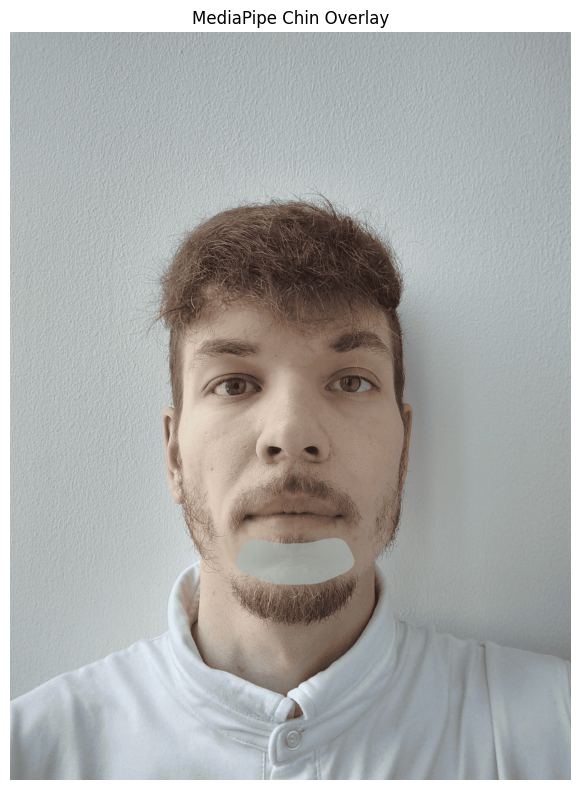

In [8]:
# Display result
plt.figure(figsize=(8, 8))
plt.imshow(final_image)
plt.axis("off")
plt.title("MediaPipe Chin Overlay")
plt.tight_layout()
plt.show()

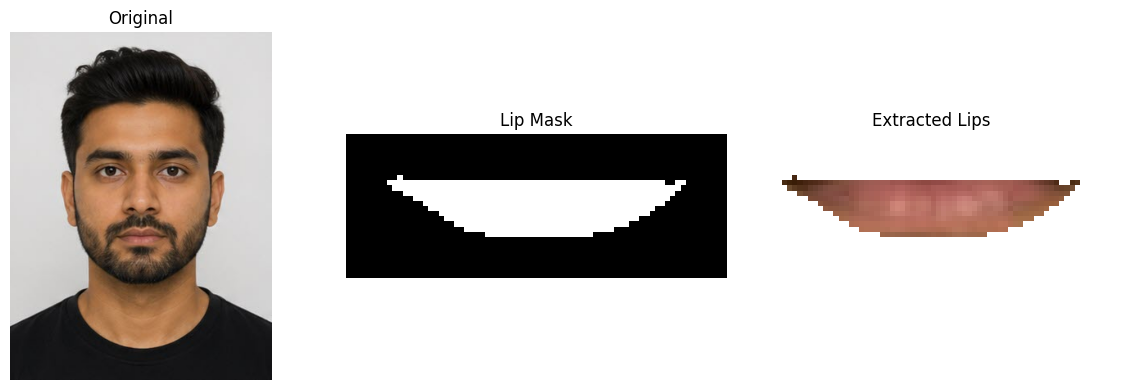

In [9]:
# Detect face landmarks and extract lips

mp_image = mp.Image(
    image_format=mp.ImageFormat.SRGB,
    data=image_rgb
)

detection_result = landmarker.detect(mp_image)

if not detection_result.face_landmarks:
    raise Exception("No face detected.")

landmarks = detection_result.face_landmarks[0]

# ----------------------------
# Image size
# ----------------------------
h, w = image_rgb.shape[:2]

# ----------------------------
# MediaPipe Lip Landmarks
# ----------------------------

OUTER_LIPS = [
    61,146,91,181,84,17,314,405,321,375,
    291,308,324,318,402,317,14,87,178,88,
    95,78
]

INNER_LIPS = [
    78,191,80,81,82,13,312,311,310,415,
    308,324,318,402,317,14,87,178,88,95
]

# ----------------------------
# Convert to pixel coordinates
# ----------------------------

outer_pts = np.array([
    [int(landmarks[i].x * w), int(landmarks[i].y * h)]
    for i in OUTER_LIPS
], dtype=np.int32)

inner_pts = np.array([
    [int(landmarks[i].x * w), int(landmarks[i].y * h)]
    for i in INNER_LIPS
], dtype=np.int32)

# ----------------------------
# Create lip mask
# ----------------------------

mask = np.zeros((h, w), dtype=np.uint8)

# Outer lips
cv2.fillPoly(mask, [outer_pts], 255)

# Remove mouth opening
cv2.fillPoly(mask, [inner_pts], 0)

# ----------------------------
# Extract lips
# ----------------------------

lips = cv2.bitwise_and(image_rgb, image_rgb, mask=mask)

# ----------------------------
# Crop tightly
# ----------------------------

x, y, ww, hh = cv2.boundingRect(outer_pts)

padding = 8

x = max(0, x - padding)
y = max(0, y - padding)

ww = min(w - x, ww + padding * 2)
hh = min(h - y, hh + padding * 2)

cropped_lips = lips[y:y+hh, x:x+ww]
cropped_mask = mask[y:y+hh, x:x+ww]

# Optional: white background instead of black
white = np.full_like(cropped_lips, 255)
white[cropped_mask > 0] = cropped_lips[cropped_mask > 0]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(image_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(cropped_mask, cmap="gray")
plt.title("Lip Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(white)
plt.title("Extracted Lips")
plt.axis("off")

plt.tight_layout()
plt.show()

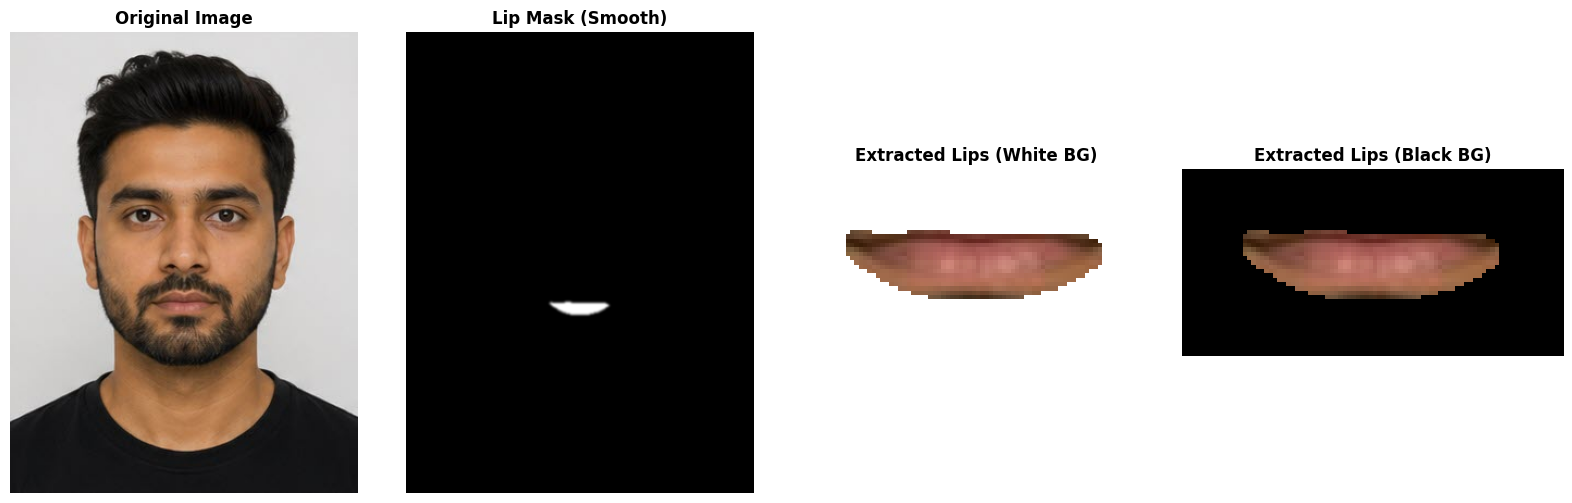

Lips saved as 'lips_white_bg.png' and 'lips_black_bg.png'


In [10]:

# Detect face landmarks
mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)
detection_result = landmarker.detect(mp_image)
 
if not detection_result.face_landmarks:
    raise Exception("No face detected.")
 
landmarks = detection_result.face_landmarks[0]
 
# MediaPipe Lip Landmarks - Complete contours
OUTER_LIPS = [
    61, 146, 91, 181, 84, 17, 314, 405, 321, 375,
    291, 308, 324, 318, 402, 317, 14, 87, 178, 88, 95, 78
]
 
INNER_LIPS = [
    78, 191, 80, 81, 82, 13, 312, 311, 310, 415,
    308, 324, 318, 402, 317, 14, 87, 178, 88, 95
]
 
def get_smooth_polygon(indices, smoothing_factor=0.01):
    """Create smooth polygon using B-spline interpolation"""
    pts = np.array([
        [landmarks[idx].x * w, landmarks[idx].y * h]
        for idx in indices
    ], dtype=np.float32)
    
    # Close the polygon
    pts = np.vstack((pts, pts[0]))
    
    # Apply B-spline interpolation
    tck, u = splprep(
        [pts[:, 0], pts[:, 1]],
        s=smoothing_factor,
        per=True,
        k=3
    )
    
    # Generate smooth curve
    unew = np.linspace(0, 1, 200)
    out = splev(unew, tck)
    
    return np.int32(np.vstack((out[0], out[1])).T)
 
# Get smooth lip contours
outer_lip_smooth = get_smooth_polygon(OUTER_LIPS, smoothing_factor=0.5)
inner_lip_smooth = get_smooth_polygon(INNER_LIPS, smoothing_factor=0.3)
 
# Create lip mask
mask = np.zeros((h, w), dtype=np.uint8)
 
# Fill outer lips
cv2.fillPoly(mask, [outer_lip_smooth], 255)
 
# Remove inner mouth opening
cv2.fillPoly(mask, [inner_lip_smooth], 0)
 
# Apply morphological operations for smooth mask
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=1)
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
 
# Apply Gaussian blur for smooth edges
mask = cv2.GaussianBlur(mask, (5, 5), 0)
 
# Extract lips using mask
lips = cv2.bitwise_and(image_rgb, image_rgb, mask=mask)
 
# Get bounding rectangle
x, y, ww, hh = cv2.boundingRect(outer_lip_smooth)
 
# Add padding with safety checks
padding = 15
x = max(0, x - padding)
y = max(0, y - padding)
ww = min(w - x, ww + padding * 2)
hh = min(h - y, hh + padding * 2)
 
# Crop extracted lips
cropped_lips = lips[y:y+hh, x:x+ww]
cropped_mask = mask[y:y+hh, x:x+ww]
 
# Create clean background (white)
white_bg = np.full_like(cropped_lips, 255)
# Apply anti-aliasing by using the mask value
for c in range(3):
    white_bg[:, :, c] = np.where(
        cropped_mask > 0,
        cropped_lips[:, :, c],
        255
    )
 
# Alternative: Black background
black_bg = np.zeros_like(cropped_lips)
black_bg = cv2.bitwise_and(cropped_lips, cropped_lips, mask=cropped_mask)
 
# Display results
plt.figure(figsize=(16, 5))
 
plt.subplot(1, 4, 1)
plt.imshow(image_rgb)
plt.title("Original Image", fontsize=12, fontweight='bold')
plt.axis("off")
 
plt.subplot(1, 4, 2)
plt.imshow(mask, cmap="gray")
plt.title("Lip Mask (Smooth)", fontsize=12, fontweight='bold')
plt.axis("off")
 
plt.subplot(1, 4, 3)
plt.imshow(white_bg)
plt.title("Extracted Lips (White BG)", fontsize=12, fontweight='bold')
plt.axis("off")
 
plt.subplot(1, 4, 4)
plt.imshow(black_bg)
plt.title("Extracted Lips (Black BG)", fontsize=12, fontweight='bold')
plt.axis("off")
 
plt.tight_layout()
plt.show()
 
# Optional: Save extracted lips
cv2.imwrite('lips_white_bg.png', cv2.cvtColor(white_bg, cv2.COLOR_RGB2BGR))
cv2.imwrite('lips_black_bg.png', black_bg)
print("Lips saved as 'lips_white_bg.png' and 'lips_black_bg.png'")